In [1]:
from pathlib import Path

if not Path('car_fuel_efficiency.csv').is_file():
    ! wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('car_fuel_efficiency.csv')

In [4]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

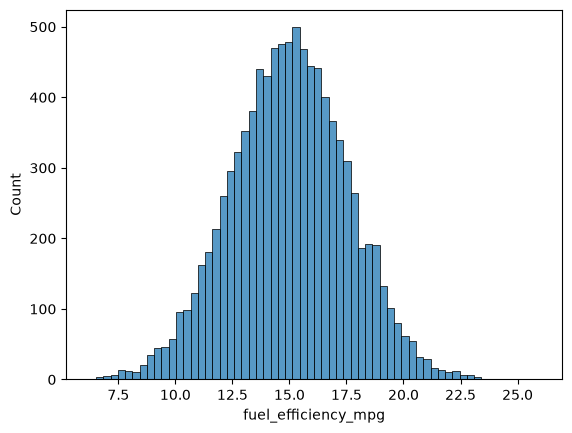

In [5]:
sns.histplot(df['fuel_efficiency_mpg'])

In [6]:
df.isna().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [7]:
base_columns = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']

In [8]:
df[base_columns]

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369
...,...,...,...,...,...
9699,140,164.0,2981.107371,2013,15.101802
9700,180,154.0,2439.525729,2004,17.962326
9701,220,138.0,2583.471318,2008,17.186587
9702,230,177.0,2905.527390,2011,15.331551


In [9]:
df.horsepower.describe()

count    8996.000000
mean      149.657292
std        29.879555
min        37.000000
25%       130.000000
50%       149.000000
75%       170.000000
max       271.000000
Name: horsepower, dtype: float64

In [10]:
df = df[base_columns]

n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

n_train, n_val, n_test

(5824, 1940, 1940)

In [11]:
np.random.seed(42)

idx = np.arange(n)
np.random.shuffle(idx)

df = df.iloc[idx]

In [12]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train + n_val]
df_test = df.iloc[n_train + n_val:]

y_train = df_train['fuel_efficiency_mpg']
y_val = df_val['fuel_efficiency_mpg']
y_test = df_test['fuel_efficiency_mpg']

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']


In [13]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year
483,220,144.0,2535.887591,2009
7506,160,141.0,2741.170484,2019
8795,230,155.0,2471.880237,2017
1688,150,206.0,3748.164469,2015
6217,300,111.0,2135.716359,2006


In [14]:
df_val.head()

,engine_displacement,horsepower,vehicle_weight,model_year
6163,180,112.0,2772.134410,2020
3313,260,138.0,3014.061530,2022
4781,140,181.0,3652.186151,2016
8210,270,105.0,2753.040847,2023
6713,170,224.0,4163.375137,2003


In [15]:
df_test.head()

,engine_displacement,horsepower,vehicle_weight,model_year
3729,140,148.0,2704.826005,2017
7764,210,136.0,3001.227490,2004
4358,210,152.0,3747.467392,2021
5922,190,128.0,2705.833636,2014
1343,230,156.0,2505.939657,2005


In [16]:
df.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [17]:
def train_linear_regression(X: pd.DataFrame, y, r=0.0):
    ones = np.ones(X.shape[0])
    
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    # add eye
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    
    w_full = XTX_inv.dot(X.T).dot(y)
    
    w0 = w_full[0]
    w = w_full[1:]
    
    return w0, w

In [18]:
def rmse(g_x, y):
    
    error = g_x - y
    square = error ** 2
    mse = np.mean(square)
    
    rmse = np.sqrt(mse)
    
    return round(rmse, 3)

In [19]:
def prepare_df_with_zero(df: pd.DataFrame):
    df = df.copy()
    df['horsepower'] = df['horsepower'].fillna(0)
    
    return df


In [20]:
def prepare_df_with_mean(df: pd.DataFrame):
    df = df.copy()
    df['horsepower'] = df['horsepower'].fillna(df.horsepower.mean())
    
    return df

### Train linear regression with zero for null values

In [21]:
X_train_zero = prepare_df_with_zero(df_train)

w0_zero, w_zero = train_linear_regression(X_train_zero, y_train)

y_pred_zero = w0_zero + X_train_zero.dot(w_zero)
y_pred_zero

483     17.335262
7506    16.292963
8795    17.698851
1688    11.472499
6217    19.231459
          ...    
1696    16.965155
5685     9.939299
6735    17.545413
2052    18.782875
1776    17.865648
Length: 5824, dtype: float64

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

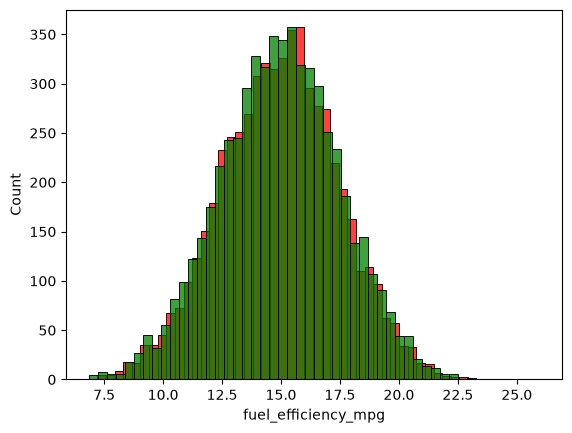

In [22]:
sns.histplot(y_pred_zero, bins=50, color='red')
sns.histplot(y_train, bins=50, color="green")

In [23]:
rmse(y_pred_zero, y_train)

np.float64(0.52)

### Train linear regression with mean for null values

In [24]:
X_train_mean = prepare_df_with_mean(df_train)
w0_mean, w_mean = train_linear_regression(X_train_mean, y_train)

y_pred_mean = w0_mean + X_train_mean.dot(w_mean)
y_pred_mean


483     17.259110
7506    16.190113
8795    17.692459
1688    11.814410
6217    18.934381
          ...    
1696    16.856287
5685     9.785104
6735    17.516664
2052    18.778124
1776    17.845934
Length: 5824, dtype: float64

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

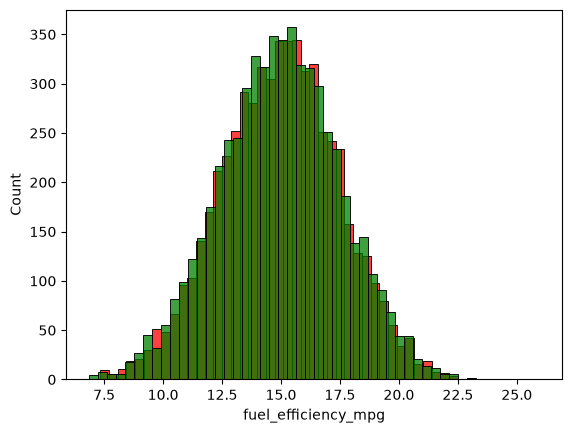

In [25]:
sns.histplot(y_pred_mean, bins=50, color="red")
sns.histplot(y_train, bins=50, color="green")

In [26]:
rmse(y_pred_mean, y_train)

np.float64(0.462)

### Linear Regression with Regulirization

In [27]:
R = [0, 0.01, 0.1, 1, 5, 10, 100]

X_train = prepare_df_with_zero(df_train)
X_val = prepare_df_with_zero(df_val)
for r in R:
    w0, w = train_linear_regression(X_train, y_train, r)
    y_pred = w0 + X_val.dot(w)
    root_mean_square_error = rmse(y_pred, y_val)
    
    print("r:", r, root_mean_square_error)
    

r: 0 0.517
r: 0.01 0.517
r: 0.1 0.519
r: 1 0.522
r: 5 0.523
r: 10 0.523
r: 100 0.523
